# Data learning curve — CNN-max & CNN-concat (curated peaks)

How does **test** peak-MAE improve as the **training set grows**? We hold out a **fixed 15% test set**
(seed 0) from the curated 758-sample dataset (**85/15** train/test), then train each model on increasing
fractions of the remaining **85% training pool** and evaluate on that same fixed test set.

- Architectures: **cnn-max** and **cnn-concat** (CNN over ESM-2 embeddings).
- **80 epochs** per fit (fixed, no val/early-stopping — we report test MAE after 80 epochs).
- Training-data fractions: **10% / 20% / 50% / 80% / 100%** of the 85% pool.
- Each train-size point is averaged over **3 random subset draws** (seeds 0–2) → mean ± std error bands.
- Targets standardized on each train subset; loss = standardized-peak MSE (Adam 1e-3, wd 1e-4, dropout 0.2).

## 0. Setup — curated data, embeddings, fixed test split

In [1]:
import csv, os, numpy as np, torch
import peak_models as pm
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC=True
except Exception: HAVE_APC=False
import matplotlib.pyplot as plt
def C(k): return getattr(apc,k) if HAVE_APC else {"aegean":"#2b6c8f","amber":"#f6a200","rose":"#c5474b","seaweed":"#3b8a6e","gray":"#888"}.get(k,"#333")
dev=torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available()) else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
TD="training_data"; CUR=f"{TD}/curated"
rows=list(csv.DictReader(open(f"{CUR}/peak_assignments.csv"))); N=len(rows)
peaks=np.load(f"{CUR}/peaks.npy").astype(np.float32)
keep=np.load(f"{CUR}/keep_index.npy")
H=np.load(f"{TD}/esm_residue_fp16.npy")[keep]; Ls=np.load(f"{TD}/esm_residue_len.npy")[keep]
Lmax=int(Ls.max()); H=H[:,:Lmax]; Ht=torch.tensor(H); ar=torch.arange(Lmax)
Pk=torch.tensor(peaks,device=dev)

# fixed held-out test set = 15% (seed 0); the rest (85%) is the training pool
perm=np.random.default_rng(0).permutation(N); n_te=int(round(0.15*N))
TEST=perm[:n_te]; POOL=perm[n_te:]
print(f"curated N={N} | fixed 15% test={len(TEST)} | 85% training pool={len(POOL)}")

def batches(idx,bs=32,shuffle=False,rng=None):
    idx=np.array(idx)
    if shuffle: rng.shuffle(idx)
    for i in range(0,len(idx),bs):
        b=idx[i:i+bs]; yield Ht[b].float().to(dev),(ar.unsqueeze(0)<torch.tensor(Ls[b]).unsqueeze(1)).to(dev),b
def test_mae(net,idx):
    net.eval(); ps=[]
    with torch.no_grad():
        for Hb,mk,b in batches(idx): ps.append(net(Hb,mk).cpu().numpy())
    P=np.concatenate(ps); T=peaks[idx]
    return 0.5*(np.abs(P[:,0]-T[:,0]).mean()+np.abs(P[:,1]-T[:,1]).mean())
def train_eval(pool, tr_idx, te_idx, seed):
    torch.manual_seed(seed); rng=np.random.default_rng(100+seed)
    mean=peaks[tr_idx].mean(0); std=peaks[tr_idx].std(0)+1e-6; sd=torch.tensor(std,device=dev)
    net=pm.wrap(pm.build_base(dict(arch="cnn",pool=pool,conv_ch=128,k=5,hidden=256,nl=2),dev,drop=0.2),mean,std,dev)
    opt=torch.optim.Adam(net.parameters(),1e-3,weight_decay=1e-4)
    for ep in range(80):
        net.train()
        for Hb,mk,b in batches(tr_idx,shuffle=True,rng=rng):
            opt.zero_grad(); (((net(Hb,mk)-Pk[torch.as_tensor(b,device=dev)])/sd)**2).mean().backward(); opt.step()
    return test_mae(net,te_idx), test_mae(net,tr_idx)

curated N=758 | fixed 15% test=114 | 85% training pool=644


## 1. Sweep training-set size (3 subset draws per point)

In [2]:
FRACS=[0.1,0.2,0.5,0.8,1.0]; SEEDS=[0,1,2]; POOLS=["max","concat"]
res={p:{"n":[],"frac":[],"te_mean":[],"te_std":[],"tr_mean":[]} for p in POOLS}
for pool in POOLS:
    print(f"--- cnn-{pool} ---")
    for f in FRACS:
        n=int(round(f*len(POOL)))
        te,tr=[],[]
        for sd in SEEDS:
            sub=np.random.default_rng(sd).choice(POOL, n, replace=False)
            t_te,t_tr=train_eval(pool, sub, TEST, sd); te.append(t_te); tr.append(t_tr)
        r=res[pool]; r["n"].append(n); r["frac"].append(f)
        r["te_mean"].append(np.mean(te)); r["te_std"].append(np.std(te)); r["tr_mean"].append(np.mean(tr))
        print(f"  {int(f*100):3d}% pool | n_train={n:4d} | test MAE {np.mean(te):5.2f} ± {np.std(te):4.2f} nm | train MAE {np.mean(tr):5.2f}")

--- cnn-max ---


   10% pool | n_train=  64 | test MAE 25.99 ± 1.14 nm | train MAE  3.34


   20% pool | n_train= 129 | test MAE 24.21 ± 2.20 nm | train MAE 12.35


   50% pool | n_train= 322 | test MAE 18.27 ± 0.91 nm | train MAE  4.95


   80% pool | n_train= 515 | test MAE 15.68 ± 0.22 nm | train MAE  4.72


...

   10% pool | n_train=  64 | test MAE 25.28 ± 2.24 nm | train MAE  4.20


   20% pool | n_train= 129 | test MAE 27.40 ± 5.25 nm | train MAE 15.99


   50% pool | n_train= 322 | test MAE 18.71 ± 0.85 nm | train MAE  6.85


   80% pool | n_train= 515 | test MAE 14.95 ± 1.21 nm | train MAE  4.62


  100% pool | n_train= 644 | test MAE 14.14 ± 0.62 nm | train MAE  5.29


## 2. Learning curve

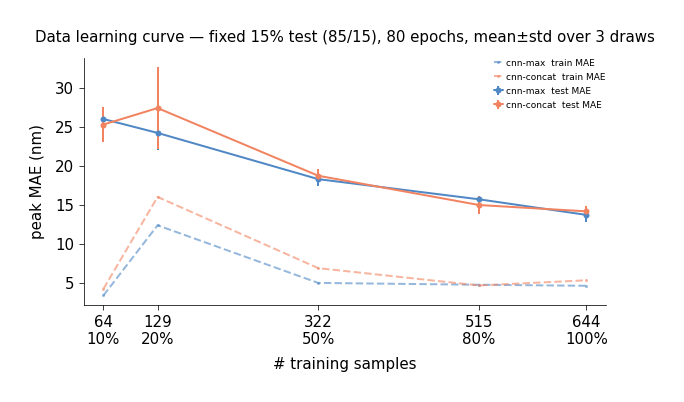

cnn-max: test MAE 26.0 nm @ 64 (10%) -> 13.7 nm @ 644 (100%)
cnn-concat: test MAE 25.3 nm @ 64 (10%) -> 14.1 nm @ 644 (100%)


In [3]:
fig,ax=plt.subplots(figsize=(8.5,5.2))
col={"max":C("aegean"),"concat":C("amber")}
for pool in POOLS:
    r=res[pool]; n=np.array(r["n"])
    ax.errorbar(n,r["te_mean"],yerr=r["te_std"],marker="o",capsize=3,color=col[pool],label=f"cnn-{pool}  test MAE")
    ax.plot(n,r["tr_mean"],ls="--",marker=".",color=col[pool],alpha=0.6,label=f"cnn-{pool}  train MAE")
ax.set_xlabel("# training samples"); ax.set_ylabel("peak MAE (nm)")
ax.set_title("Data learning curve — fixed 15% test (85/15), 80 epochs, mean±std over 3 draws")
ax.legend(fontsize=9)
ax.set_xticks(res["max"]["n"])
ax.set_xticklabels([f'{n}\n{int(f*100)}%' for n,f in zip(res["max"]["n"],res["max"]["frac"])])
plt.tight_layout(); fig.savefig("trained_models/data_learning_curve_85_15.png",dpi=130,bbox_inches="tight"); plt.show()
for pool in POOLS:
    r=res[pool]; print(f"cnn-{pool}: test MAE {r['te_mean'][0]:.1f} nm @ {r['n'][0]} (10%) -> {r['te_mean'][-1]:.1f} nm @ {r['n'][-1]} (100%)")

## Notes
- This is a **data** learning curve (test error vs training-set size), distinct from the per-epoch curve.
  Test set is fixed (**15%**, seed 0) so points are comparable; training subsets are drawn from the
  remaining **85%** pool.
- Training-data fractions: **10 / 20 / 50 / 80 / 100%** of the 85% pool. 80 epochs per fit (no val selection).
  Bands are ±1 std over 3 random subset draws per size.
- A still-falling test curve at 100% ⇒ more data would help; a flattening curve + shrinking train↔test gap
  ⇒ data-limited returns. Compare cnn-max vs cnn-concat for which scales better.